In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, train_test_split

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
df=pd.read_csv(r"C:\Users\omkar\OneDrive\Documents\Internship\Heart Disease\heart.csv")


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
X=df.drop('target', axis=1)

In [6]:
df1=pd.read_csv(r"C:\Users\omkar\OneDrive\Documents\Internship\Heart Disease\heart.csv")


In [7]:
y=df1["target"]

In [8]:
X=X.fillna(0)
y=y.fillna(0)

In [9]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)
dt = DecisionTreeClassifier(random_state=42)


In [12]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [13]:

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=3, n_jobs=-1, verbose=2)
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=3, n_jobs=-1, verbose=2)

In [14]:
grid_search_dt.fit(X_train, y_train)

Fitting 3 folds for each of 1152 candidates, totalling 3456 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 5, 10, 20],
                         'splitter': ['best', 'random']},
             verbose=2)

In [15]:
print("Best parameters found by Grid Search:")
print(grid_search_dt.best_params_)

Best parameters found by Grid Search:
{'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}


In [16]:
from sklearn.metrics import accuracy_score

In [17]:
best_grid_dt = grid_search_dt.best_estimator_
y_pred_grid_dt = best_grid_dt.predict(X_test)
print("Test set accuracy of best Grid Search model:")
print(accuracy_score(y_test, y_pred_grid_dt))

Test set accuracy of best Grid Search model:
0.819672131147541


In [18]:
grid_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 288 candidates, totalling 864 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100, 200]},
             verbose=2)

In [19]:
print(grid_search_rf.best_params_)

{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 10}


In [20]:
best_grid_rf = grid_search_rf.best_estimator_
y_pred_grid_rf= best_grid_rf.predict(X_test)
print("Test set accuracy of best Grid Search model:")
print(accuracy_score(y_test, y_pred_grid_rf))

Test set accuracy of best Grid Search model:
0.8360655737704918


In [21]:
from sklearn.ensemble import  VotingClassifier

In [22]:
ensemble_classifier = VotingClassifier(estimators=[('dt', best_grid_dt), ('rf', best_grid_rf)], voting='hard')


In [23]:
ensemble_classifier.fit(X_train, y_train)

VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(min_samples_leaf=4,
                                                     min_samples_split=10,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(bootstrap=False,
                                                     min_samples_leaf=2,
                                                     n_estimators=10,
                                                     random_state=42))])

In [24]:
y_pred_ensemble = ensemble_classifier.predict(X_test)

In [25]:
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)

In [26]:
print("Accuracy of Ensemble Classifier:", accuracy_ensemble)

Accuracy of Ensemble Classifier: 0.7868852459016393


In [27]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [28]:
cm1 = confusion_matrix(y_test, y_pred_grid_rf, labels=[0, 1])
cm2 = confusion_matrix(y_test, y_pred_grid_dt, labels=[0, 1 ])
cm3 = confusion_matrix(y_test, y_pred_ensemble, labels=[0, 1 ])

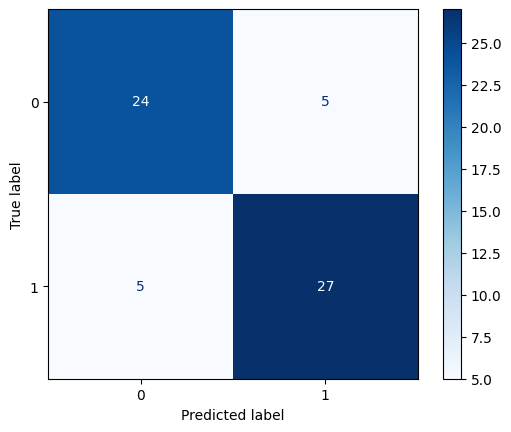

In [29]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

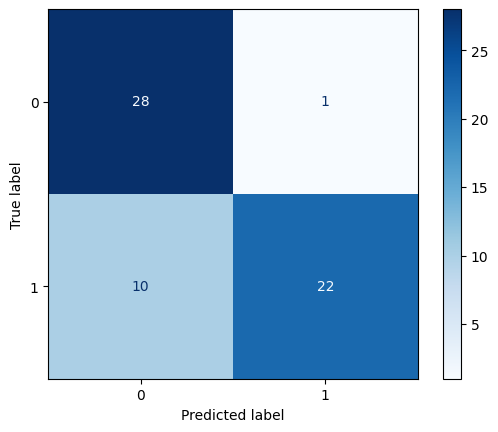

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

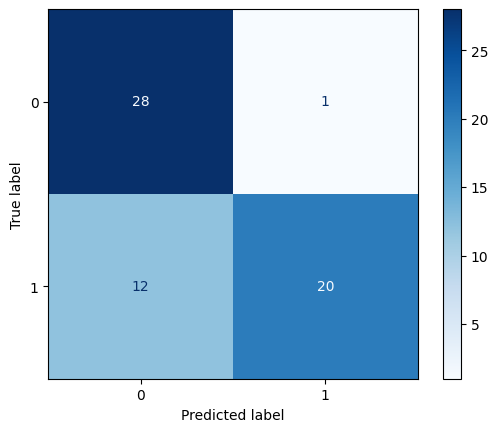

In [31]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [32]:
from sklearn.svm import SVC

In [33]:
svm_classifier = SVC(kernel='linear', random_state=42)

In [34]:
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [35]:
y_pred = svm_classifier.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)

In [37]:
from sklearn.metrics import accuracy_score, classification_report

In [38]:
report = classification_report(y_test, y_pred)
print("SVM Classification Report:")
print(report)

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
classifiers = {
    'Logistic Regression' :LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear'),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

Training and evaluating Logistic Regression...
Logistic Regression Accuracy: 0.8852459016393442
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



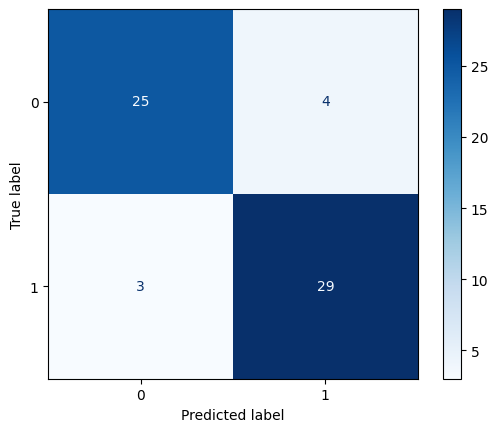

Training and evaluating SVM...
SVM Accuracy: 0.8688524590163934
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



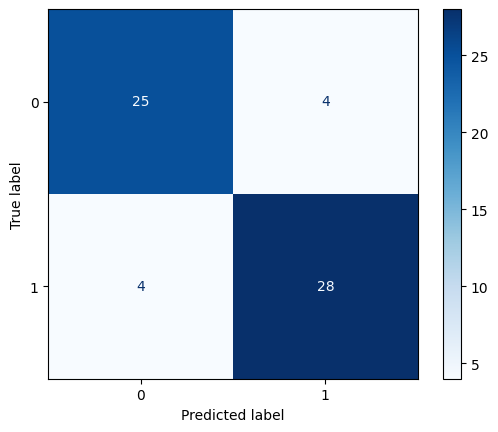

Training and evaluating Random Forest...
Random Forest Accuracy: 0.819672131147541
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



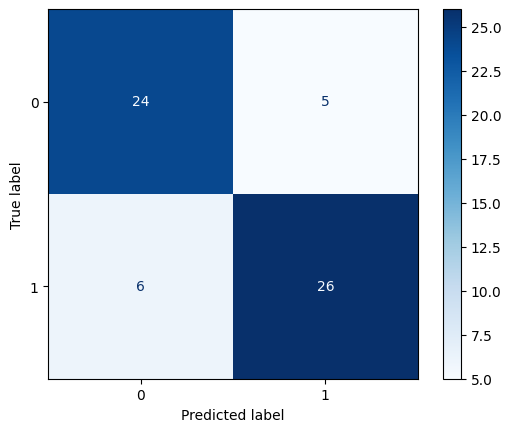

Training and evaluating Naive Bayes...
Naive Bayes Accuracy: 0.8688524590163934
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



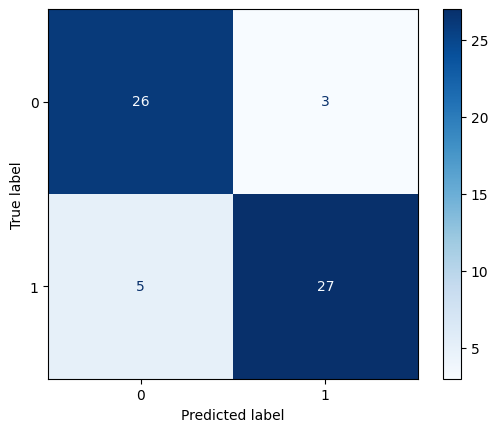

Training and evaluating K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.6885245901639344
K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.62      0.65        29
           1       0.69      0.75      0.72        32

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



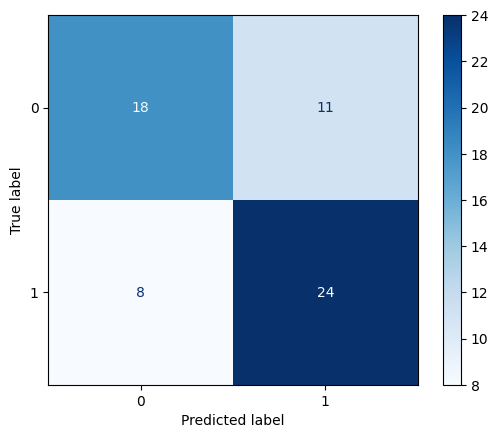

In [42]:
for clf_name, clf in classifiers.items():
    print(f"Training and evaluating {clf_name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{clf_name} Accuracy: {accuracy}")
    print(f"{clf_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1 ])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.show()
    
    